In [1]:
import sys, os, importlib
sys.path.append('../')

import scripts.analytics
import scripts.algorithms

f = sys.stdout
sys.stdout = open(os.devnull, 'w')

importlib.reload(scripts.analytics)
importlib.reload(scripts.algorithms)

import numpy as np
import pandas as pd

sys.stdout.close()
sys.stdout = f

In [2]:
name = "studentmath"
namex = "Math"
d = 30

###knn
graphs = np.load("../graphs/"+name+"_knn_random.npy", allow_pickle=True)
###threshold
graphsz = np.load("../graphs/"+name+"_thresh_random.npy", allow_pickle=True)


# Standard model results

## Nearest neighbor

In [3]:
graphsinfor = []
for iz in range(len(graphs)):
    
    avg_left_deg, avg_left_pos_deg, avg_left_neg_deg, avg_right_deg, \
    avg_overlap,  avg_pos_overlap, avg_neg_overlap, only_pos, only_neg, \
    empty_adj, unipos  = scripts.analytics.getconnectivity_info(graphs[iz]["edges"], graphs[iz]["labels"])

    graphsinfor.append({
        "Dataset (d)": namex+" ("+ str(d) + ")",
        "kmax": graphs[iz]["k_max"], 
        "n": graphs[iz]['n'],
        "m": graphs[iz]['m'],
        "#+ves": len({t for t, l in graphs[iz]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphs[iz]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_deg,2), 
        "avg LHS+d": round(avg_left_pos_deg,2), 
        "avg LHS-d": round(avg_left_neg_deg,2),   
        "avg RHSd": round(avg_right_deg,2),          
        "avg overlap": round(avg_overlap,2), 
        "avg overlap+": round(avg_pos_overlap,2), 
        "avg overlap-": round(avg_neg_overlap,2), 
        "only+Ns": only_pos,
        "only-Ns": only_neg,
        "emptyNs": empty_adj,
        "uni+": unipos,
        "graphID": iz
    })

randomgraphsinfo = pd.DataFrame(graphsinfor)   
randomgraphsinfo



,Dataset (d),kmax,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Math (30),1,206,35,16,19,1.0,0.51,0.49,5.89,0.04,0.02,0.01,106,100,0,0,0
1,Math (30),2,206,38,17,21,2.0,1.04,0.96,10.84,0.17,0.10,0.07,60,52,0,0,1
2,Math (30),3,206,39,17,22,3.0,1.46,1.54,15.85,0.38,0.19,0.20,21,30,0,0,2
3,Math (30),4,206,39,17,22,4.0,2.01,1.99,21.13,0.66,0.33,0.33,13,14,0,0,3
4,Math (30),5,206,39,17,22,5.0,2.58,2.42,26.41,1.01,0.53,0.48,5,8,0,0,4
5,Math (30),6,206,39,17,22,6.0,3.05,2.95,31.69,1.46,0.74,0.72,5,6,0,0,5
6,Math (30),7,206,39,17,22,7.0,3.65,3.35,36.97,1.95,1.04,0.91,1,2,0,0,6
7,Math (30),8,206,39,17,22,8.0,4.18,3.82,42.26,2.47,1.34,1.13,0,1,0,0,7
8,Math (30),9,206,39,17,22,9.0,4.76,4.24,47.54,3.08,1.72,1.36,0,0,0,0,8
9,Math (30),10,206,39,17,22,10.0,5.27,4.73,52.82,3.76,2.09,1.67,0,0,0,0,9


In [4]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfo))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & kmax & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Math & (30) & 1 & 206 & 35 & 16 & 19 & 1.0 & 0.51 & 0.49 & 5.89 & 0.04 & 0.02 & 0.01 & 106 & 100 & 0 & 0 & 0 \\
Math & (30) & 2 & 206 & 38 & 17 & 21 & 2.0 & 1.04 & 0.96 & 10.84 & 0.17 & 0.10 & 0.07 & 60 & 52 & 0 & 0 & 1 \\
Math & (30) & 3 & 206 & 39 & 17 & 22 & 3.0 & 1.46 & 1.54 & 15.85 & 0.38 & 0.19 & 0.20 & 21 & 30 & 0 & 0 & 2 \\
Math & (30) & 4 & 206 & 39 & 17 & 22 & 4.0 & 2.01 & 1.99 & 21.13 & 0.66 & 0.33 & 0.33 & 13 & 14 & 0 & 0 & 3 \\
Math & (30) & 5 & 206 & 39 & 17 & 22 & 5.0 & 2.58 & 2.42 & 26.41 & 1.01 & 0.53 & 0.48 & 5 & 8 & 0 & 0 & 4 \\
Math & (30) & 6 & 206 & 39 & 17 & 22 & 6.0 & 3.05 & 2.95 & 31.69 & 1.46 & 0.74 & 0.72 & 5 & 6 & 0 & 0 & 5 \\
Math & (30) & 7 & 206 & 39 & 17 & 22 & 7.0 & 3.65 & 3.35 & 36.97 & 1.95 & 1.04 & 0.91 &

## Thresholding

In [5]:
graphsinforx = []
for ix in range(len(graphsz)):
    
    avg_left_degx, avg_left_pos_degx, avg_left_neg_degx, avg_right_degx, \
    avg_overlapx, avg_pos_overlapx, avg_neg_overlapx, only_posx, only_negx, \
    empty_adjx, uniposx  = scripts.analytics.getconnectivity_info(graphsz[ix]["edges"], graphsz[ix]["labels"])
        
    graphsinforx.append({
        "Dataset (d)":namex+" ("+ str(d) + ")",
        "r": graphsz[ix]["threshold"], 
        "n": graphsz[ix]['n'],
        "m": graphsz[ix]['m'],
        "#+ves": len({t for t, l in graphsz[ix]['labels'].items() if l == 1}),
        "#-ves": len({t for t, l in graphsz[ix]['labels'].items() if l == -1}), 
        "avg LHSd": round(avg_left_degx,2),  
        "avg LHS+d": round(avg_left_pos_degx,2),  
        "avg LHS-d": round(avg_left_neg_degx,2),   
        "avg RHSd": round(avg_right_degx,2),          
        "avg overlap": round(avg_overlapx,2), 
        "avg overlap+": round(avg_pos_overlapx,2), 
        "avg overlap-": round(avg_neg_overlapx,2), 
        "only+Ns": only_posx,
        "only-Ns": only_negx,
        "emptyNs": empty_adjx,
        "uni+": uniposx,
        "graphID": ix
    })

randomgraphsinfox = pd.DataFrame(graphsinforx)   
randomgraphsinfox


,Dataset (d),r,n,m,#+ves,#-ves,avg LHSd,avg LHS+d,avg LHS-d,avg RHSd,avg overlap,avg overlap+,avg overlap-,only+Ns,only-Ns,emptyNs,uni+,graphID
0,Math (30),4.0,206,9,5,4,0.09,0.06,0.03,2.11,0.01,0.00,0.00,10,5,190,1,0
1,Math (30),4.5,206,16,7,9,0.21,0.11,0.10,2.75,0.01,0.01,0.01,14,13,174,0,1
2,Math (30),5.0,206,24,12,12,0.58,0.37,0.21,5.00,0.04,0.03,0.02,25,19,145,0,2
3,Math (30),5.5,206,32,15,17,1.71,0.97,0.75,11.03,0.20,0.12,0.08,24,34,97,0,3
4,Math (30),6.0,206,38,17,21,3.63,2.04,1.59,19.68,0.68,0.40,0.28,21,27,61,0,4
5,Math (30),6.5,206,39,17,22,7.09,3.90,3.19,37.46,2.09,1.22,0.87,8,22,33,0,5
6,Math (30),7.0,206,39,17,22,11.81,6.23,5.58,62.38,4.92,2.77,2.15,8,23,9,0,6
7,Math (30),7.5,206,39,17,22,17.55,8.96,8.60,92.72,9.74,5.19,4.55,2,12,3,0,7
8,Math (30),8.0,206,39,17,22,23.30,11.57,11.72,123.05,15.82,8.20,7.62,0,8,1,0,8
9,Math (30),8.5,206,39,17,22,28.29,13.67,14.62,149.44,22.13,11.16,10.96,1,3,0,0,9


In [6]:
print(scripts.analytics.df_to_latex_preserve(randomgraphsinfox))

\begin{tabular}{llllllllllllllllllllllllll}
Dataset & (d) & r & n & m & #+ves & #-ves & avg & LHSd & avg & LHS+d & avg & LHS-d & avg & RHSd & avg & overlap & avg & overlap+ & avg & overlap- & only+Ns & only-Ns & emptyNs & uni+ & graphID \\
\hline
Math & (30) & 4.0 & 206 & 9 & 5 & 4 & 0.09 & 0.06 & 0.03 & 2.11 & 0.01 & 0.00 & 0.00 & 10 & 5 & 190 & 1 & 0 \\
Math & (30) & 4.5 & 206 & 16 & 7 & 9 & 0.21 & 0.11 & 0.10 & 2.75 & 0.01 & 0.01 & 0.01 & 14 & 13 & 174 & 0 & 1 \\
Math & (30) & 5.0 & 206 & 24 & 12 & 12 & 0.58 & 0.37 & 0.21 & 5.00 & 0.04 & 0.03 & 0.02 & 25 & 19 & 145 & 0 & 2 \\
Math & (30) & 5.5 & 206 & 32 & 15 & 17 & 1.71 & 0.97 & 0.75 & 11.03 & 0.20 & 0.12 & 0.08 & 24 & 34 & 97 & 0 & 3 \\
Math & (30) & 6.0 & 206 & 38 & 17 & 21 & 3.63 & 2.04 & 1.59 & 19.68 & 0.68 & 0.40 & 0.28 & 21 & 27 & 61 & 0 & 4 \\
Math & (30) & 6.5 & 206 & 39 & 17 & 22 & 7.09 & 3.90 & 3.19 & 37.46 & 2.09 & 1.22 & 0.87 & 8 & 22 & 33 & 0 & 5 \\
Math & (30) & 7.0 & 206 & 39 & 17 & 22 & 11.81 & 6.23 & 5.58 & 62.38 &

# Load the algorithmic results

In [7]:
greedy_bruteforce_algosdf = pd.read_csv("./sm_results/"+name+"_knn_greedy_rdm_bruteforce.csv")
all_bruteforce = pd.read_csv("./sm_results/"+name+"_knn_allbruteforce.csv")

greedy_bruteforce_algosdfz = pd.read_csv("./sm_results/"+name+"_thresh_greedy_rdm_bruteforce.csv")
all_bruteforcez = pd.read_csv("./sm_results/"+name+"_thresh_allbruteforce.csv")


In [8]:
summary_df = pd.read_csv("./sm_results/"+name+"_knn_summary.csv")
greedyalgo_df = pd.read_csv("./sm_results/"+name+"_knn_greedyheuristic.csv")
randomalgo_df = pd.read_csv("./sm_results/"+name+"_knn_randomheuristic.csv")


summary_dfx = pd.read_csv("./sm_results/"+name+"_thresh_summary.csv")
greedyalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_greedyheuristic.csv")
randomalgo_dfx = pd.read_csv("./sm_results/"+name+"_thresh_randomheuristic.csv")


# Compute social welfare given an empty set

## Nearest neighbor

In [9]:
results_knn = []

for lx in range(len(graphs)):

    r_edges_randomx  = graphs[lx]["edges"]
    r_labels_randomx = graphs[lx]["labels"]
    
    
    ###############
    Sx = set()
    cur_utility = scripts.algorithms.F_S(r_edges_randomx, r_labels_randomx, Sx)

    
    ###############
    for Kx in [1, 2, 3, 4, 5]:
        
        #######
        results_knn.append({
            "kmax": graphs[lx]["k_max"],
            "graphid": lx,
            "K": Kx,
            "F(So)": cur_utility


        })


mddfa = summary_df.merge(pd.DataFrame(results_knn), on=["kmax", "graphid", "K"], how="left")

mdf = mddfa.merge(greedy_bruteforce_algosdf[["kmax", "graphid", "K", "F(S*)"]], on=["kmax", "graphid", "K"], how="left")

pd.DataFrame(results_knn).tail()


,kmax,graphid,K,F(So)
45,10,9,1,108.6
46,10,9,2,108.6
47,10,9,3,108.6
48,10,9,4,108.6
49,10,9,5,108.6


## Thresholding

In [10]:
results_thresh = []

for lz in range(len(graphsz)):

    r_edges_randomz  = graphsz[lz]["edges"]
    r_labels_randomz = graphsz[lz]["labels"]
    
    
    ###############
    Sz = set()
    cur_utilityz = scripts.algorithms.F_S(r_edges_randomz, r_labels_randomz, Sz)

    
    ###############
    for Kz in [1, 2, 3, 4, 5]:
        
        #######
        results_thresh.append({
            "r": graphsz[lz]["threshold"],
            "graphid": lz,
            "K": Kz,
            "F(So)": cur_utilityz


        })

        
mddfaz = summary_dfx.merge(pd.DataFrame(results_thresh), on=["r", "graphid", "K"], how="left")

mdfz = mddfaz.merge(greedy_bruteforce_algosdfz[["r", "graphid", "K", "F(S*)"]], on=["r", "graphid", "K"], how="left")

pd.DataFrame(results_thresh).tail()


,r,graphid,K,F(So)
60,10.0,12,1,91.686768
61,10.0,12,2,91.686768
62,10.0,12,3,91.686768
63,10.0,12,4,91.686768
64,10.0,12,5,91.686768


# Standard model results plots

## Nearest neighbor

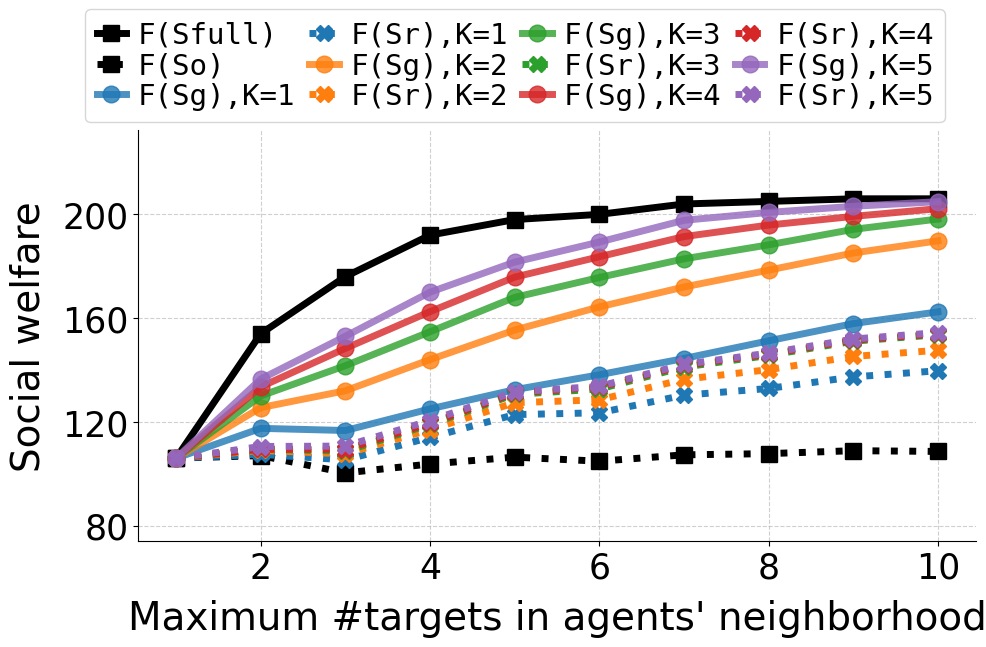

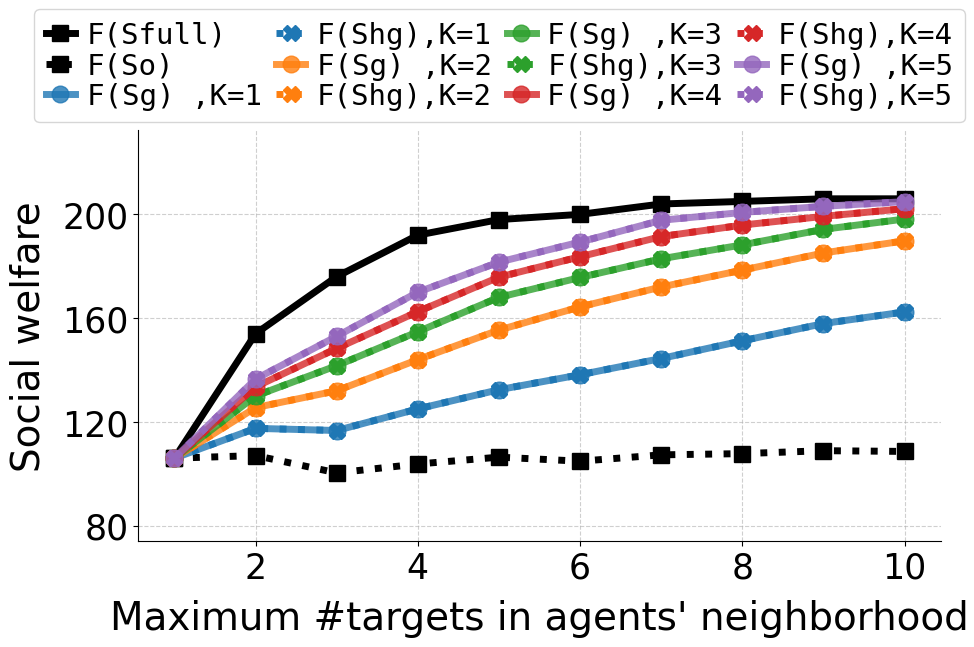

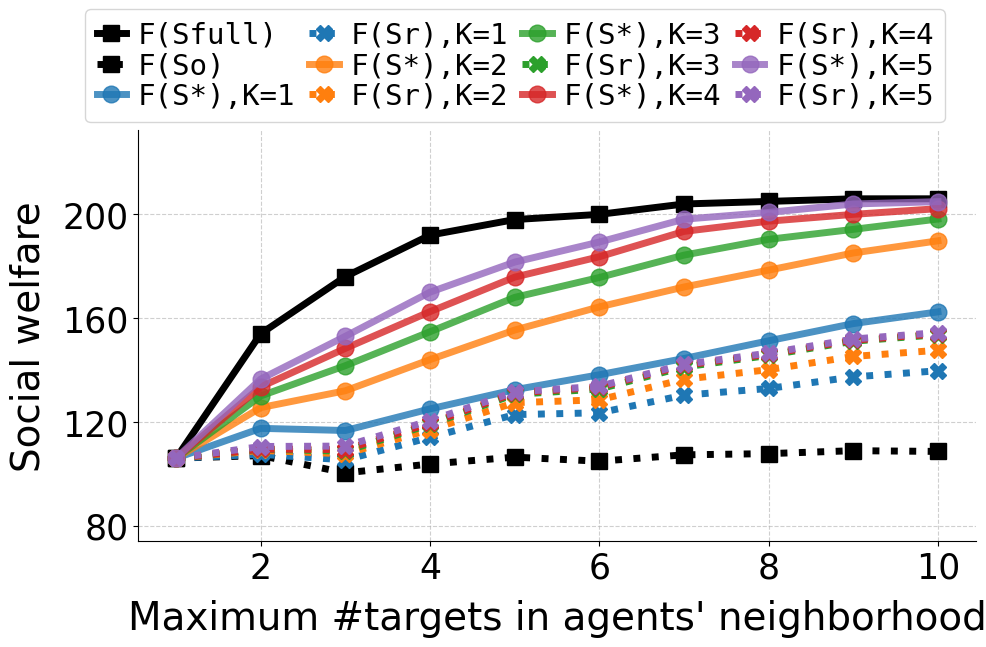

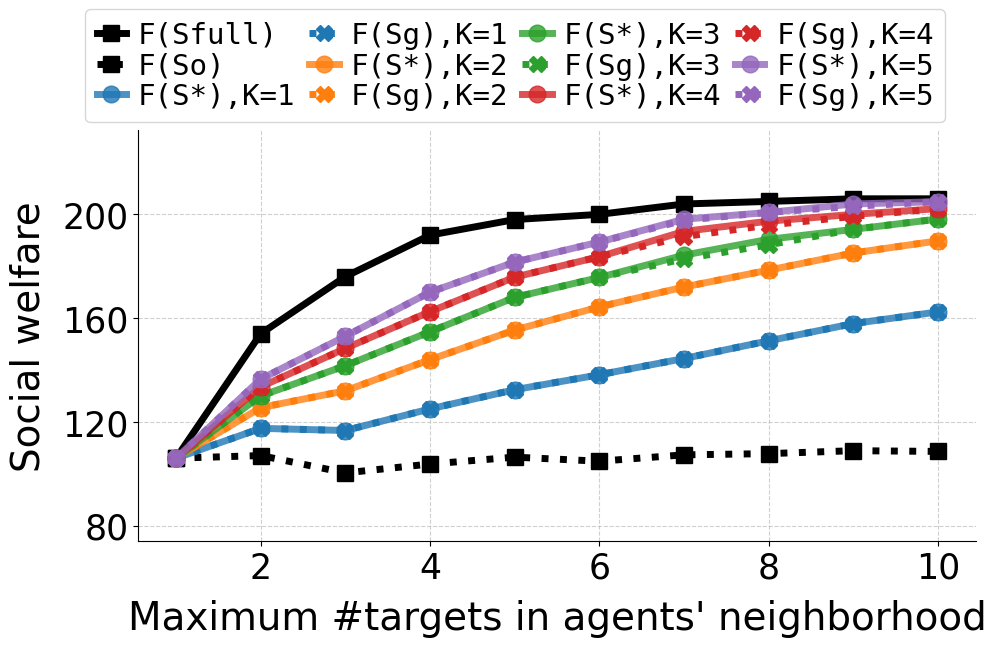

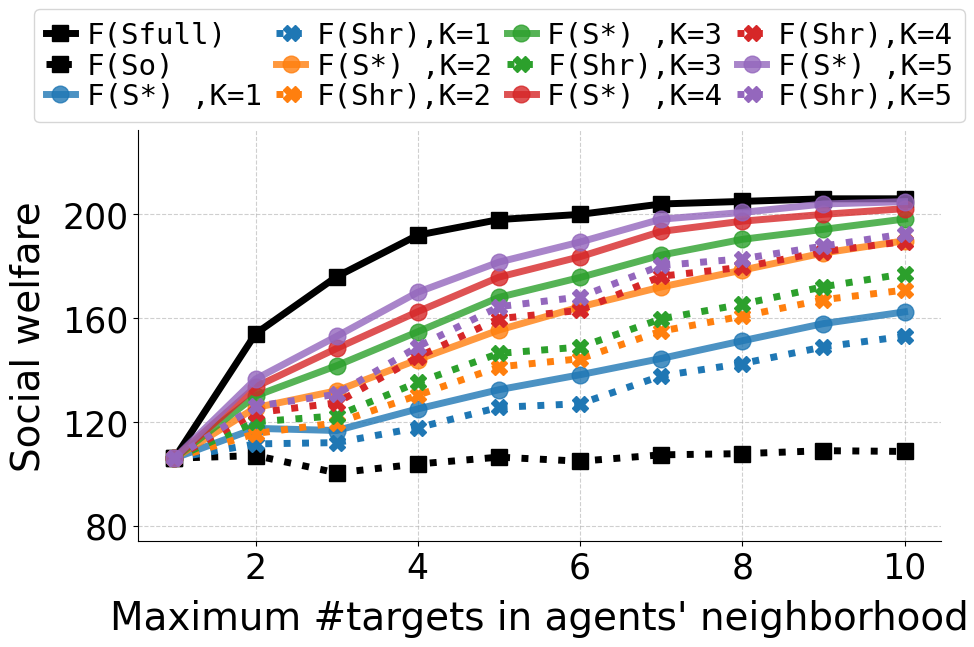

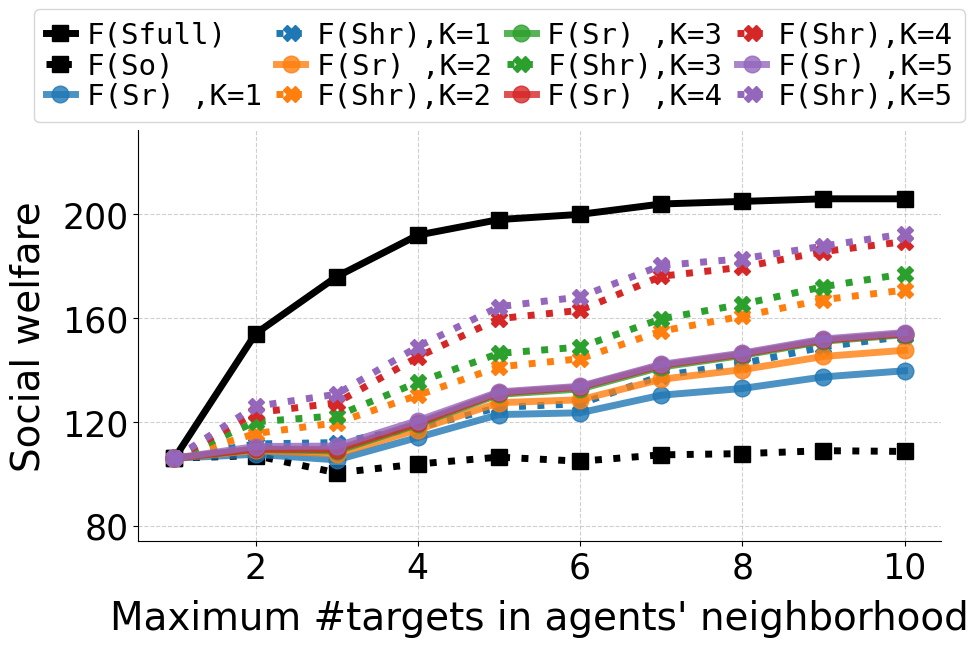

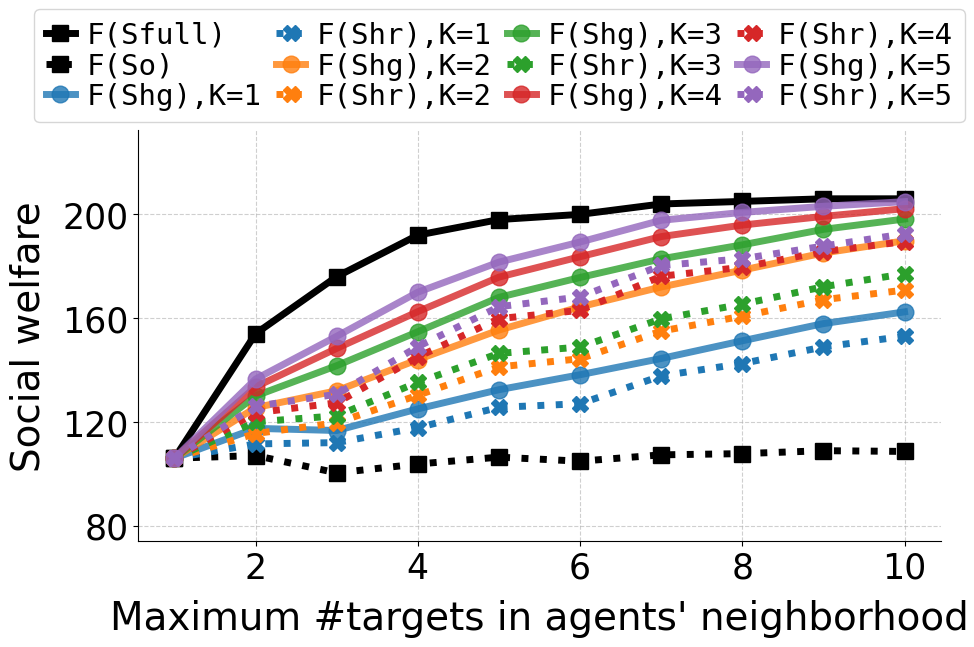

In [11]:
daz1 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2, x_col="kmax", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",   
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_knn.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz144 = mdf[["K", "F(Sg)", "F(Sr)", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz144, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz244 = mdf[["K", "F(Sg)", "F(Sg+ U Sg-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz244, x_col="kmax", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz245 = mdf[["K", "F(Sg)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz245, x_col="kmax", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)


    
###########################
daz3 = mdf[["K", "F(Sr)", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz3, x_col="kmax", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz4 = mdf[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "kmax", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz4, x_col="kmax", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_knn.pdf",
                                   figsize=(10, 7), showfig=True)

    
    

## Thresholding

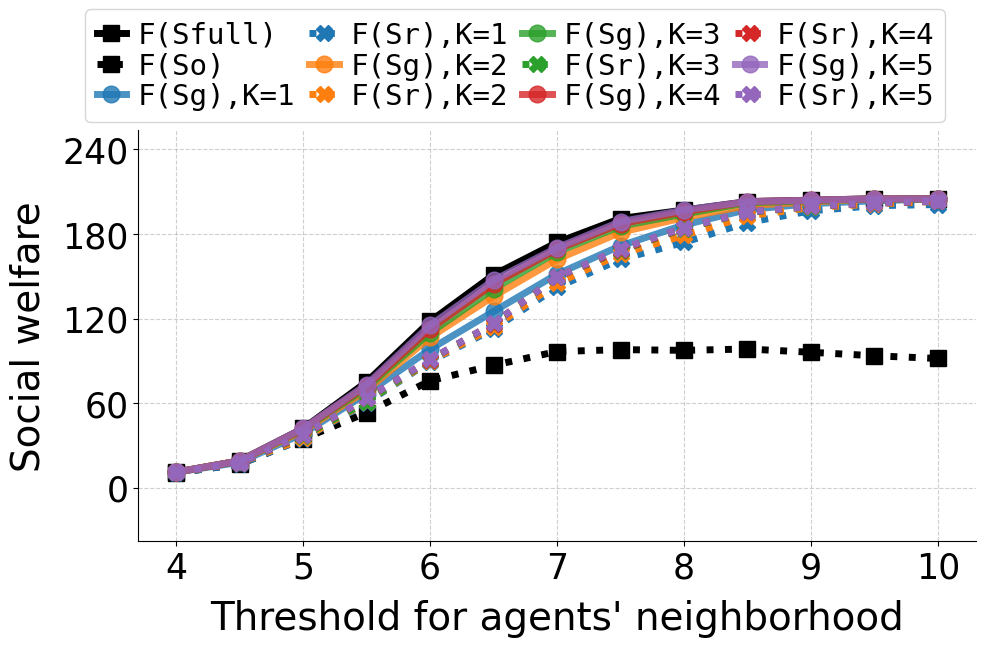

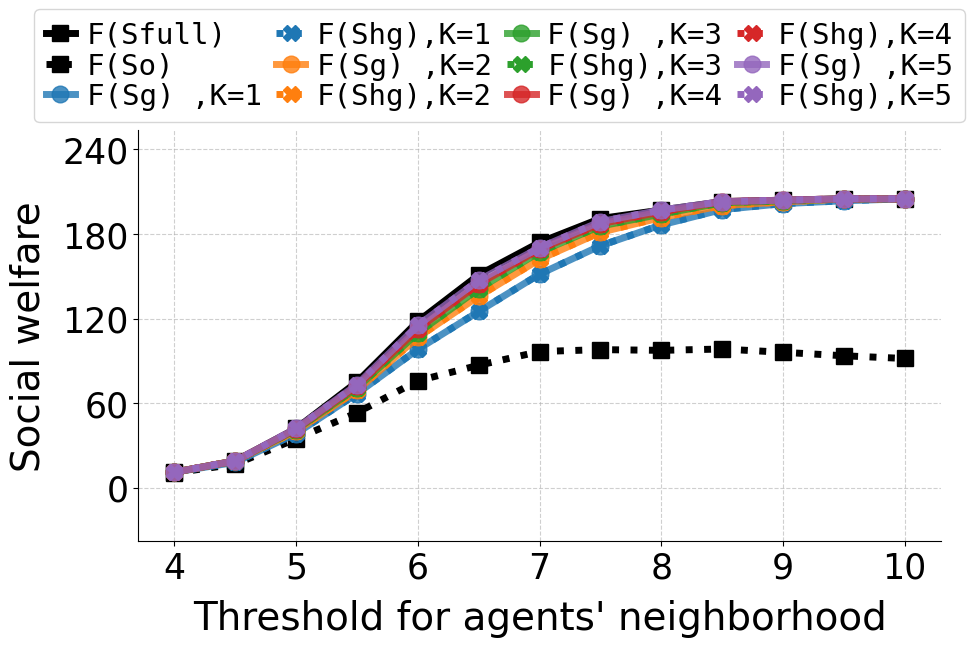

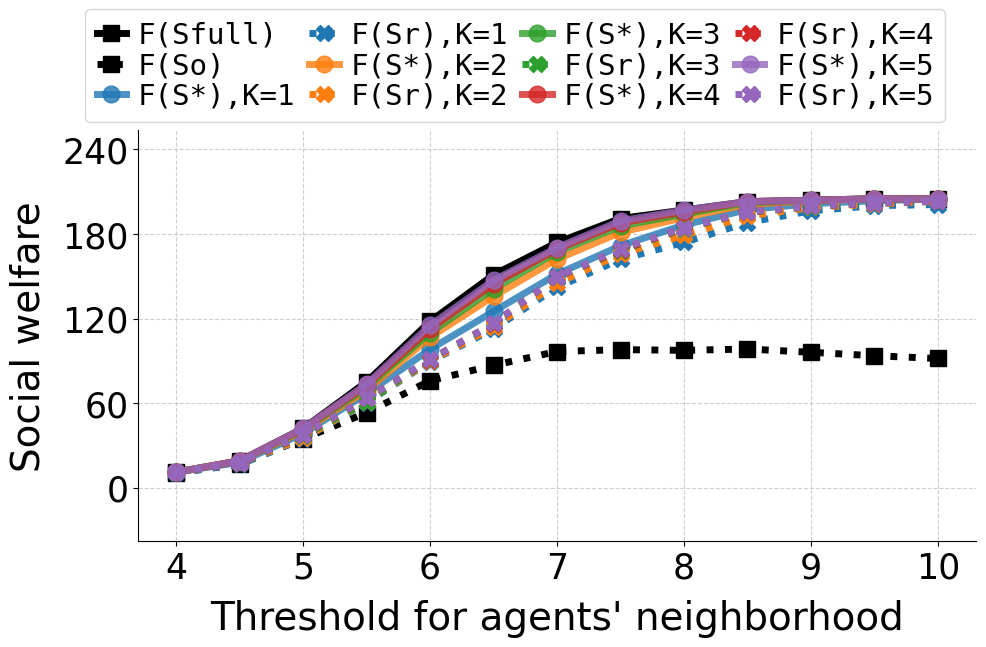

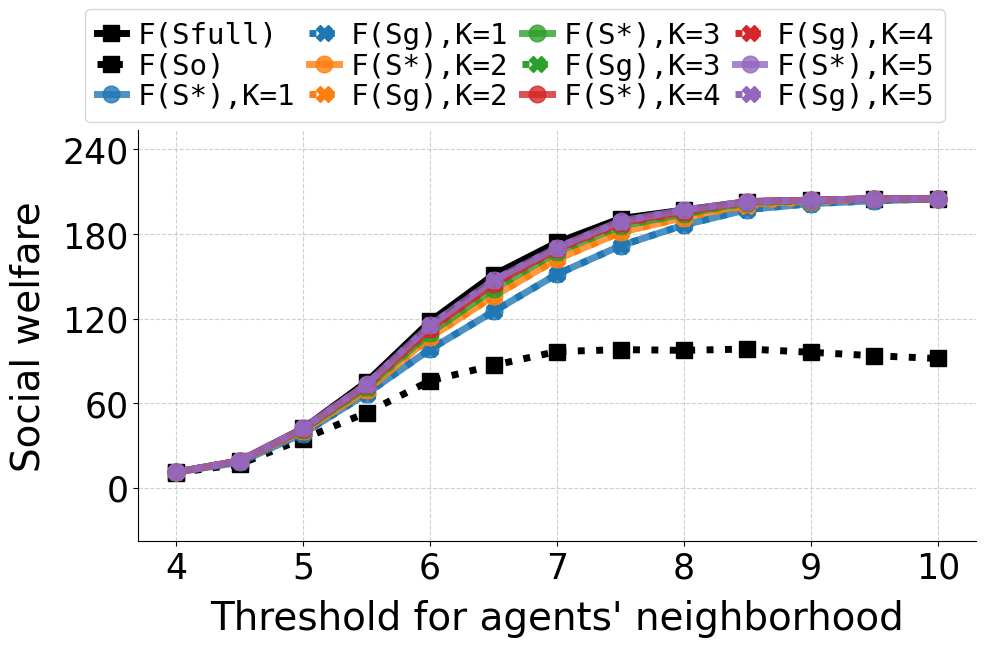

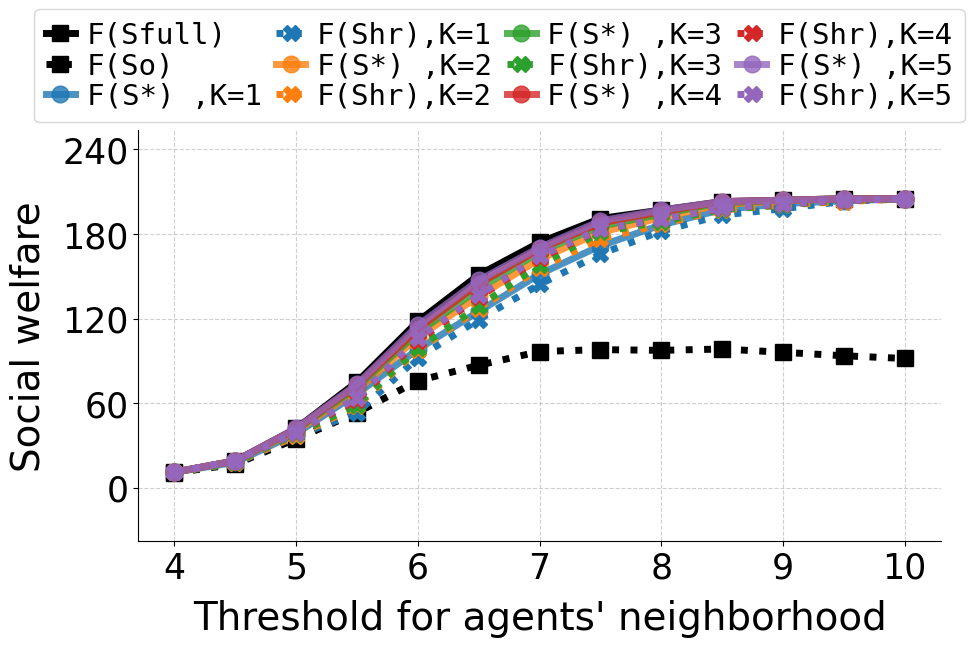

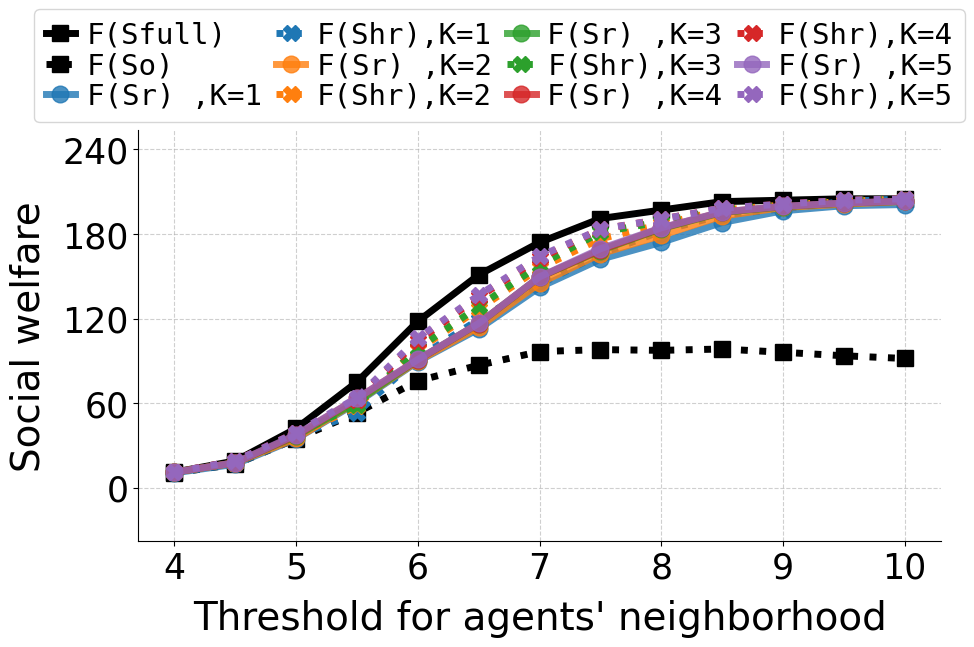

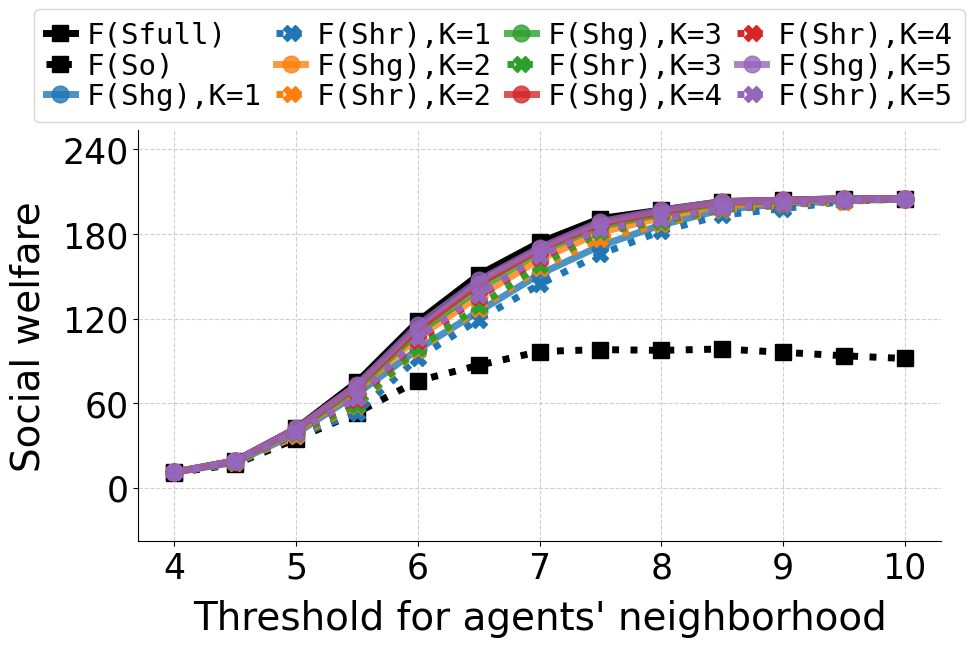

In [12]:
daz11 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz11, x_col="r", ycol1="F(Sg)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz22 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz22, x_col="r", ycol1="F(Sg)", ycol2="F(Sg+ U Sg-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sg) ,", ycol2_name="F(Shg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sg_shg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz1144 = mdfz[["K", "F(Sg)", "F(Sr)", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz1144, x_col="r", ycol1="F(S*)", ycol2="F(Sr)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)",
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


    
############################
daz2244 = mdfz[["K", "F(Sg)", "F(Sg+ U Sg-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2244, x_col="r", ycol1="F(S*)", ycol2="F(Sg)", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*),", ycol2_name="F(Sg),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_sg_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



############################
daz2245 = mdfz[["K", "F(Sg)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]
scripts.analytics.sm_results_plot(daz2245, x_col="r", ycol1="F(S*)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(S*) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", 
                                   save_as="./sm_results/figures/aplot_"+namex+"_star_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz33 = mdfz[["K", "F(Sr)", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz33, x_col="r", ycol1="F(Sr)", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Sr) ,", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_sr_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)



###########################
daz44 = mdfz[["K", "F(Sg+ U Sg-)*", "F(Sr+ U Sr-)*", "r", "F(Sgfull)", "F(So)", "F(S*)"]]

scripts.analytics.sm_results_plot(daz44, x_col="r", ycol1="F(Sg+ U Sg-)*", ycol2="F(Sr+ U Sr-)*", ycol3="F(Sgfull)", 
                                   ycol4="F(So)", ycol1_name="F(Shg),", ycol2_name="F(Shr),", ycol3_name="F(Sfull)", 
                                   ycol4_name="F(So)", ycol5="F(S*)", ycol5_name="F(S*)",  
                                   save_as="./sm_results/figures/aplot_"+namex+"_shg_shr_thresh.pdf",
                                   figsize=(10, 7), showfig=True)


  